# Tutorial: driving the network-plotting API directly

This notebook skips the GUI's **Network Viewer** tab entirely and calls
`meanap.network_plot` directly — the same module that tab uses underneath.
It's the fastest way to script batch figure generation, or to build a custom
plot MEA-NAP doesn't produce out of the box.

The data file used here, `sample_data/NGN2_20230208_P1_DIV14_A2_OutputData.mat`,
is a real MEA-NAP Python-port output file (from the same `NGN2_..._A2`
recording used as one half of the bundled "Test pipeline" example dataset —
see [Quickstart](../quickstart.md)) — every number in this notebook's plots
comes from an actual pipeline run, not synthetic data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from meanap.network_plot import MatData, plot_network

data = MatData("sample_data/NGN2_20230208_P1_DIV14_A2_OutputData.mat")

print("Available lags:", data.lag_keys)
print("Available node-level metrics:", data.available_node_metrics)
print("Total electrodes in layout:", data.coords.shape[0])


Available lags: ['adjM10mslag', 'adjM25mslag', 'adjM50mslag']
Available node-level metrics: ['aveControl', 'modalControl', 'ND', 'NS', 'Z', 'Eloc', 'PC', 'BC', 'MEW', 'activeNodeIndices', 'Ci', 'activeChannel']
Total electrodes in layout: 64


## Inspect one lag

Each STTC lag value has its own adjacency matrix and its own set of active
nodes (electrodes that passed the minimum-activity filter for that lag).


In [2]:
lag = data.lag_keys[0]
print("Using lag:", lag)

active_idx = data.get_active_indices(lag)   # 0-based indices into the full 64-electrode array
adjM = data.get_adjM(lag)[np.ix_(active_idx, active_idx)]
coords = data.coords[active_idx]

print("Active nodes:", len(active_idx), "/", data.coords.shape[0])
print("Adjacency matrix shape:", adjM.shape)


Using lag: adjM10mslag
Active nodes: 62 / 64
Adjacency matrix shape: (62, 62)


## Plot the network, colored by betweenness centrality

Node **size** is node degree (`ND`); node **color** is betweenness centrality
(`BC`), using the same viridis colormap and legend the Network Viewer GUI tab
renders.


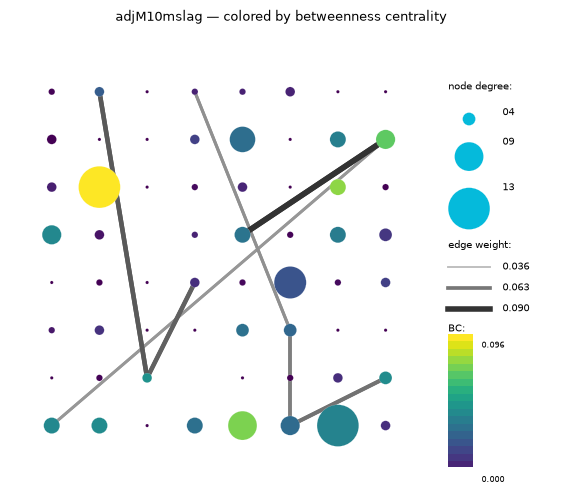

In [3]:
z = data.get_metric(lag, "ND")    # node degree -> node size
z2 = data.get_metric(lag, "BC")   # betweenness centrality -> node color

fig, ax = plt.subplots(figsize=(7, 6))
plot_network(
    ax, adjM, coords,
    edge_thresh=0.05,
    z=z,
    z2=z2,
    z2_name="BC",
    title=f"{lag} — colored by betweenness centrality",
)
plt.show()


## Compare across lags

Looping over `data.lag_keys` makes it straightforward to generate one figure
per lag value — useful for a quick side-by-side sanity check before diving
into the full report.


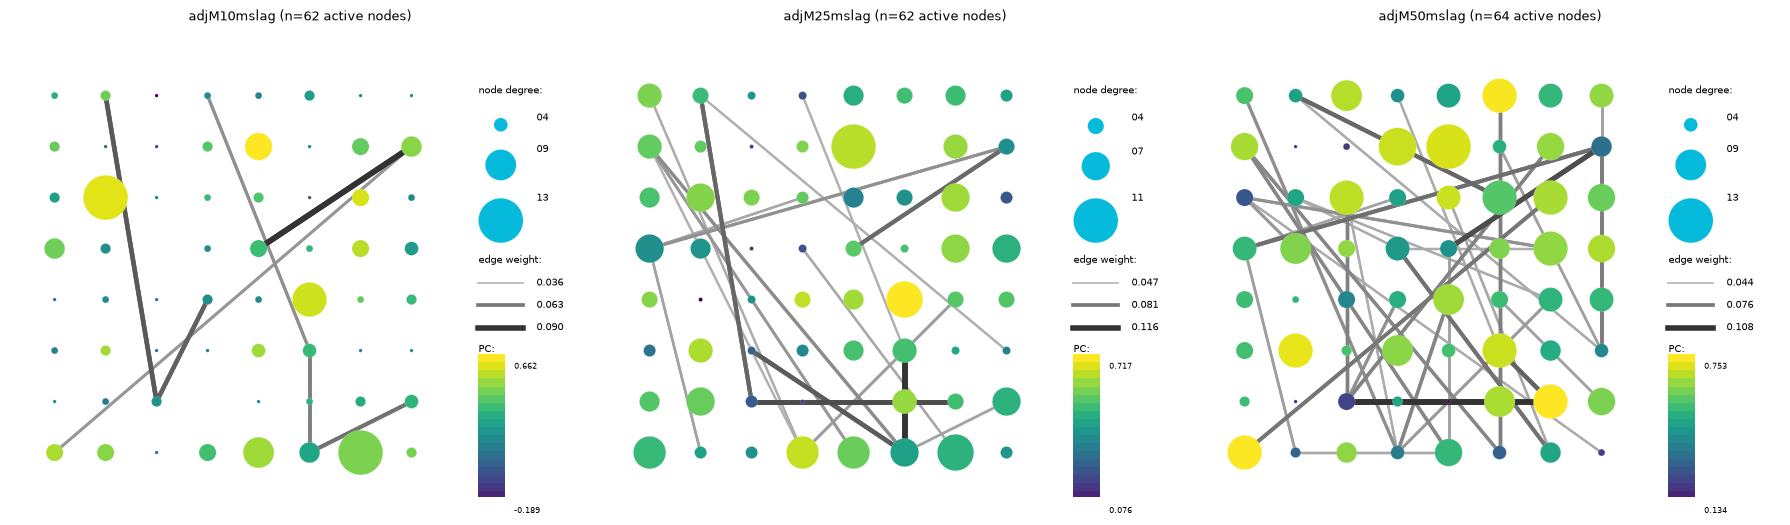

In [4]:
fig, axes = plt.subplots(1, len(data.lag_keys), figsize=(6 * len(data.lag_keys), 5))

for ax, lag in zip(axes, data.lag_keys):
    active_idx = data.get_active_indices(lag)
    adjM_lag = data.get_adjM(lag)[np.ix_(active_idx, active_idx)]
    coords_lag = data.coords[active_idx]
    z = data.get_metric(lag, "ND")
    z2 = data.get_metric(lag, "PC")

    plot_network(
        ax, adjM_lag, coords_lag,
        edge_thresh=0.05,
        z=z,
        z2=z2,
        z2_name="PC",
        title=f"{lag} (n={len(active_idx)} active nodes)",
    )

plt.tight_layout()
plt.show()


## Next steps

- Swap `"BC"` / `"PC"` for any metric in `data.available_node_metrics` — node
  strength (`NS`), module z-score (`Z`), local efficiency (`Eloc`), or the
  controllability metrics (`aveControl`, `modalControl`) all work the same
  way.
- To overlay cell-type information (e.g. `NeuN+`/`PV+` markers), see
  [Network Viewer](../network-viewer.md#cell-type-overlay) — the same
  `load_cell_type_file`/`build_cell_type_matrix`/`filter_by_cell_types`
  functions used there are importable from `meanap.network_plot` too.
- For the full function/class reference, see the [API reference](../api/index.rst).
